# Results: base vs SFT-only vs distilled

Qwen3-14B teacher -> Qwen3-4B-Instruct-2507 student (4-bit QLoRA, 240 optimizer steps, 640 Glaive tool-call examples). One full run, seed 42, Kaggle T4 x2 (run tag `v1-fixed`). Reads only the files in `results/`, so it needs no GPU and re-runs in seconds.

Evaluation: 121 synthetic tool-use tasks (46 single-step, 40 three-step, 35 five-step) with a fixed six-tool vocabulary the students were **not** trained on, plus perplexity on 200 WikiText-2 chunks. Layer analysis: linear CKA and RSA cosine distance between each student layer and the teacher, on 50 tool-use and 50 general probe texts.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
FIG.mkdir(exist_ok=True)

CONDITIONS = ["base", "sft_only", "distilled"]
LABELS = {"base": "Base", "sft_only": "SFT only", "distilled": "Distilled (KD + SFT)"}
COLORS = {"base": "#777777", "sft_only": "#0072B2", "distilled": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

rows = [json.loads(line) for line in open(RESULTS / "eval_results.jsonl", encoding="utf-8")]
tasks = pd.DataFrame(rows)[["condition", "chain_length", "task_id", "success"]]
tasks["template"] = tasks["task_id"].str.rsplit("-", n=1).str[0]
summary = json.load(open(RESULTS / "eval_summary.json", encoding="utf-8"))
print(len(tasks), "task results;", tasks["task_id"].nunique(), "distinct tasks x", tasks["condition"].nunique(), "conditions")

363 task results; 121 distinct tasks x 3 conditions


## 1. Full-chain success

In [2]:
def wilson(k, n, z=1.96):
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


counts = tasks.groupby(["condition", "chain_length"])["success"].agg(k="sum", n="count").reset_index()
counts["rate"] = counts["k"] / counts["n"]
counts[["lo", "hi"]] = [wilson(k, n) for k, n in zip(counts["k"], counts["n"])]

table = counts.assign(
    cell=lambda d: (100 * d["rate"]).round(1).astype(str) + "%  (" + d["k"].astype(int).astype(str) + "/" + d["n"].astype(str) + ")  ["
    + (100 * d["lo"]).round(0).astype(int).astype(str) + "-" + (100 * d["hi"]).round(0).astype(int).astype(str) + "]"
).pivot(index="condition", columns="chain_length", values="cell").loc[CONDITIONS]
table.index = [LABELS[c] for c in table.index]
table.columns = [f"chain length {c}" for c in table.columns]
table  # rate (successes/tasks) [95% Wilson interval]

,chain length 1,chain length 3,chain length 5
Base,93.5% (43/46) [82-98],70.0% (28/40) [55-82],74.3% (26/35) [58-86]
SFT only,95.7% (44/46) [85-99],70.0% (28/40) [55-82],68.6% (24/35) [52-81]
Distilled (KD + SFT),100.0% (46/46) [92-100],87.5% (35/40) [74-95],91.4% (32/35) [78-97]


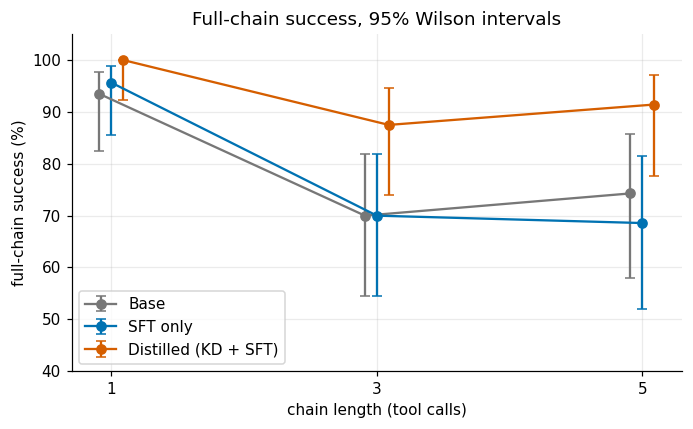

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4))
offsets = {"base": -0.09, "sft_only": 0.0, "distilled": 0.09}
for c in CONDITIONS:
    d = counts[counts["condition"] == c].sort_values("chain_length")
    x = d["chain_length"] + offsets[c]
    ax.errorbar(x, 100 * d["rate"], yerr=[100 * (d["rate"] - d["lo"]), 100 * (d["hi"] - d["rate"])],
                marker="o", capsize=3, color=COLORS[c], label=LABELS[c])
ax.set_xticks([1, 3, 5])
ax.set_xlabel("chain length (tool calls)")
ax.set_ylabel("full-chain success (%)")
ax.set_ylim(40, 105)
ax.legend(loc="lower left")
ax.set_title("Full-chain success, 95% Wilson intervals")
fig.tight_layout()
fig.savefig(FIG / "success_by_chain_length.png", dpi=200)
plt.show()

## 2. Are the differences real?

The same 121 tasks were run for every condition, so the comparison is paired: an exact McNemar test on the tasks where exactly one of the two conditions succeeded. Tasks are generated from templates (for example five weather cities for one tool sequence), so they are not independent; a template-level bootstrap interval is given next to it, and is the more honest of the two.

In [4]:
wide = tasks.pivot(index="task_id", columns="condition", values="success").astype(bool)
meta = tasks.drop_duplicates("task_id").set_index("task_id")[["chain_length", "template"]]
wide = wide.join(meta)


def contrast(a, b, mask, n_boot=10000, seed=0):
    d = wide[mask]
    only_a = int((d[a] & ~d[b]).sum())
    only_b = int((~d[a] & d[b]).sum())
    p = binomtest(only_a, only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
    diff = d[a].mean() - d[b].mean()
    rng = np.random.default_rng(seed)
    by_template = d.groupby("template")[[a, b]].agg(["sum", "count"])
    sa, ca = by_template[(a, "sum")].to_numpy(), by_template[(a, "count")].to_numpy()
    sb, cb = by_template[(b, "sum")].to_numpy(), by_template[(b, "count")].to_numpy()
    idx = rng.integers(0, len(sa), size=(n_boot, len(sa)))
    boot = sa[idx].sum(1) / ca[idx].sum(1) - sb[idx].sum(1) / cb[idx].sum(1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return {"tasks": len(d), "only_a": only_a, "only_b": only_b, "diff_pts": 100 * diff,
            "template_boot_95ci": f"[{100 * lo:+.1f}, {100 * hi:+.1f}]", "mcnemar_p": p}


subsets = {"chain 1": wide.chain_length == 1, "chain 3": wide.chain_length == 3, "chain 5": wide.chain_length == 5,
           "chains 3+5": wide.chain_length >= 3, "all 121 tasks": wide.chain_length >= 1}
pairs = [("distilled", "base"), ("distilled", "sft_only"), ("sft_only", "base")]
result = []
for a, b in pairs:
    for name, mask in subsets.items():
        result.append({"contrast": f"{LABELS[a]} - {LABELS[b]}", "subset": name, **contrast(a, b, mask)})
stats = pd.DataFrame(result)
stats["mcnemar_p"] = stats["mcnemar_p"].round(3)
stats["diff_pts"] = stats["diff_pts"].round(1)
stats.rename(columns={"only_a": "only first ok", "only_b": "only second ok"})

,contrast,subset,tasks,only first ok,only second ok,diff_pts,template_boot_95ci,mcnemar_p
0,Distilled (KD + SFT) - Base,chain 1,46,3,0,6.5,"[+0.0, +15.6]",0.250
1,Distilled (KD + SFT) - Base,chain 3,40,11,4,17.5,"[-2.5, +45.0]",0.118
2,Distilled (KD + SFT) - Base,chain 5,35,6,0,17.1,"[+2.9, +34.3]",0.031
3,Distilled (KD + SFT) - Base,chains 3+5,75,17,4,17.3,"[+4.0, +33.3]",0.007
4,Distilled (KD + SFT) - Base,all 121 tasks,121,20,4,13.2,"[+4.1, +24.8]",0.002
5,Distilled (KD + SFT) - SFT only,chain 1,46,2,0,4.3,"[+0.0, +9.1]",0.500
6,Distilled (KD + SFT) - SFT only,chain 3,40,9,2,17.5,"[+2.5, +35.0]",0.065
7,Distilled (KD + SFT) - SFT only,chain 5,35,8,0,22.9,"[+5.7, +42.9]",0.008
8,Distilled (KD + SFT) - SFT only,chains 3+5,75,17,2,20.0,"[+8.0, +32.0]",0.001
9,Distilled (KD + SFT) - SFT only,all 121 tasks,121,19,2,14.0,"[+6.2, +23.2]",0.000


Reading it: the distilled student's advantage over both other conditions is concentrated in the three- and five-step chains. SFT-only is indistinguishable from the untouched base model. Each individual chain length is small (35-46 tasks), so single-length differences are suggestive, not conclusive; check the template-bootstrap intervals above before quoting any of them.

## 3. Where the failures come from, and perplexity

In [5]:
summ = pd.DataFrame(summary["summary"])
by_cond = []
for c in CONDITIONS:
    rows_c = summ[summ["condition"] == c]
    errs = {}
    for e in rows_c["error_breakdown"]:
        for k, v in e.items():
            errs[k] = errs.get(k, 0) + v
    steps = tasks[tasks["condition"] == c]
    by_cond.append({
        "condition": LABELS[c],
        "tasks failed": int((~steps["success"]).sum()),
        "MalformedCallError": errs.get("MalformedCallError", 0),
        "WrongToolError": errs.get("WrongToolError", 0),
        "recovery rate (chains 1/3/5)": " / ".join(f"{100 * r:.0f}%" for r in rows_c.sort_values("chain_length")["recovery_rate"]),
        "perplexity": round(summary["perplexity_by_condition"][c], 2),
    })
pd.DataFrame(by_cond).set_index("condition")

,tasks failed,MalformedCallError,WrongToolError,recovery rate (chains 1/3/5),perplexity
condition,,,,,
Base,24,16,8,75% / 70% / 75%,18.31
SFT only,25,7,18,83% / 40% / 62%,17.35
Distilled (KD + SFT),8,1,7,100% / 80% / 89%,18.46


`MalformedCallError` means the model answered in prose instead of emitting a tool call; `WrongToolError` means it called a valid tool that was not the expected next one. Recovery rate is the share of injected-failure steps that the model then completed. SFT-only trades one kind of error for the other (prose answers 16 -> 7, wrong tool 8 -> 18), which fits a student that has memorised the training tools; the distilled student cuts both. Perplexity on general text barely moves under either fine-tuning, so the tool-use difference is not a side effect of the model changing in general language ability.

## 4. Training curves

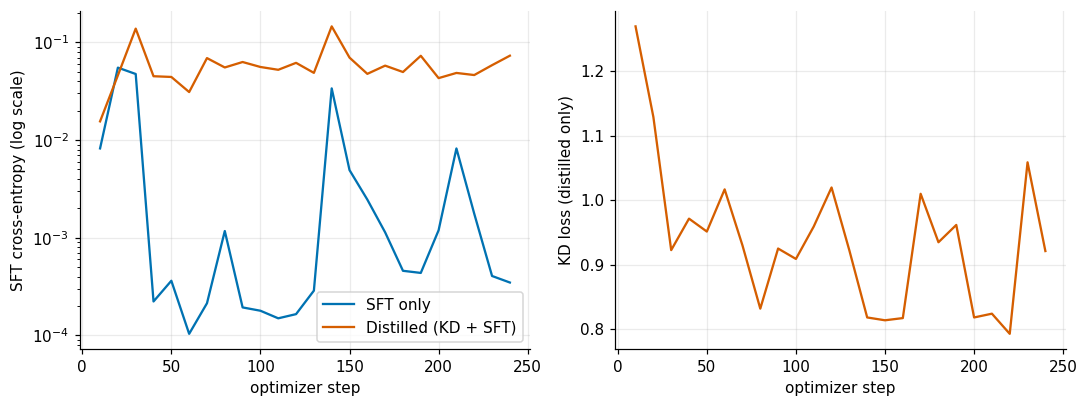

final SFT loss: sft_only 0.00035, distilled 0.07312; final KD loss 0.921


In [6]:
def read_log(name):
    return pd.read_json(RESULTS / "training_logs" / f"{name}.jsonl", lines=True)


sft, dist = read_log("sft_only"), read_log("distilled")
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(sft["step"], sft["sft_loss"], color=COLORS["sft_only"], label=LABELS["sft_only"])
axes[0].plot(dist["step"], dist["sft_loss"], color=COLORS["distilled"], label=LABELS["distilled"])
axes[0].set_yscale("log")
axes[0].set_xlabel("optimizer step")
axes[0].set_ylabel("SFT cross-entropy (log scale)")
axes[0].legend()
axes[1].plot(dist["step"], dist["kd_loss"], color=COLORS["distilled"])
axes[1].set_xlabel("optimizer step")
axes[1].set_ylabel("KD loss (distilled only)")
fig.tight_layout()
fig.savefig(FIG / "training_curves.png", dpi=200)
plt.show()
print(f"final SFT loss: sft_only {sft['sft_loss'].iloc[-1]:.5f}, distilled {dist['sft_loss'].iloc[-1]:.5f}; final KD loss {dist['kd_loss'].iloc[-1]:.3f}")

The SFT-only student drives the training cross-entropy to about 1e-4 within 40 steps, i.e. it has essentially memorised the templated training data. The distilled student keeps a cross-entropy near 0.05 and a KD loss near 0.9 throughout: the teacher's soft targets keep it from collapsing onto the hard labels. That is a plausible reason for the behavioural gap, but this run does not test it.

## 5. Layer-wise similarity to the teacher

In [7]:
div = pd.read_json(RESULTS / "layer_analysis" / "divergence.jsonl", lines=True)
means = div.groupby(["input_set", "stream", "condition"])[["cka", "cosine_distance"]].mean().unstack("condition")
means = means.reindex(columns=CONDITIONS, level=1).round(4)
means  # CKA: higher = more similar to teacher.  cosine_distance (RSA): lower = more similar

cka                    cosine_distance           \
condition              base sft_only distilled            base sft_only   
input_set stream                                                          
general   attention  0.7885   0.7880    0.7883          0.0212   0.0211   
          ffn        0.7937   0.7926    0.7947          0.0111   0.0110   
tool_use  attention  0.9091   0.9103    0.9089          0.0094   0.0096   
          ffn        0.8882   0.8867    0.8884          0.0053   0.0053   

                               
condition           distilled  
input_set stream               
general   attention    0.0213  
          ffn          0.0111  
tool_use  attention    0.0095  
          ffn          0.0053

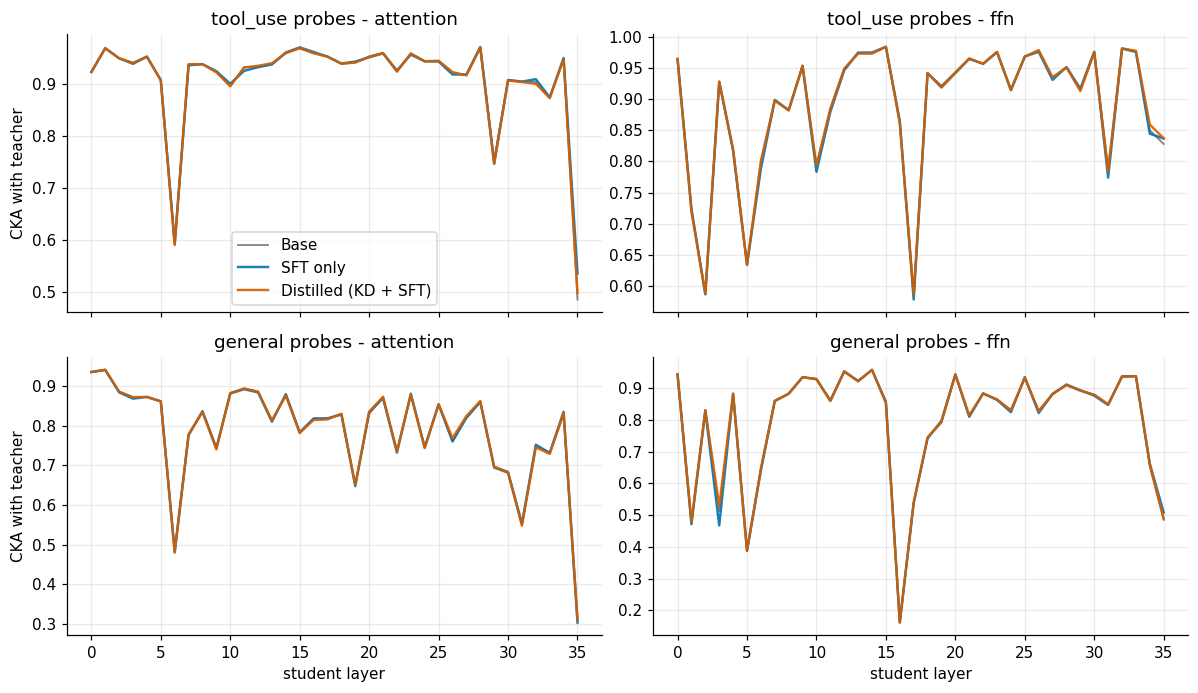

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True)
for r, input_set in enumerate(["tool_use", "general"]):
    for c_idx, stream in enumerate(["attention", "ffn"]):
        ax = axes[r][c_idx]
        for cond in CONDITIONS:
            d = div[(div.input_set == input_set) & (div.stream == stream) & (div.condition == cond)].sort_values("source_layer")
            ax.plot(d["source_layer"], d["cka"], color=COLORS[cond], label=LABELS[cond], lw=1.6 if cond != "base" else 1.2, alpha=0.9)
        ax.set_title(f"{input_set} probes - {stream}")
        if r == 1:
            ax.set_xlabel("student layer")
        if c_idx == 0:
            ax.set_ylabel("CKA with teacher")
axes[0][0].legend()
fig.tight_layout()
fig.savefig(FIG / "layer_cka.png", dpi=200)
plt.show()

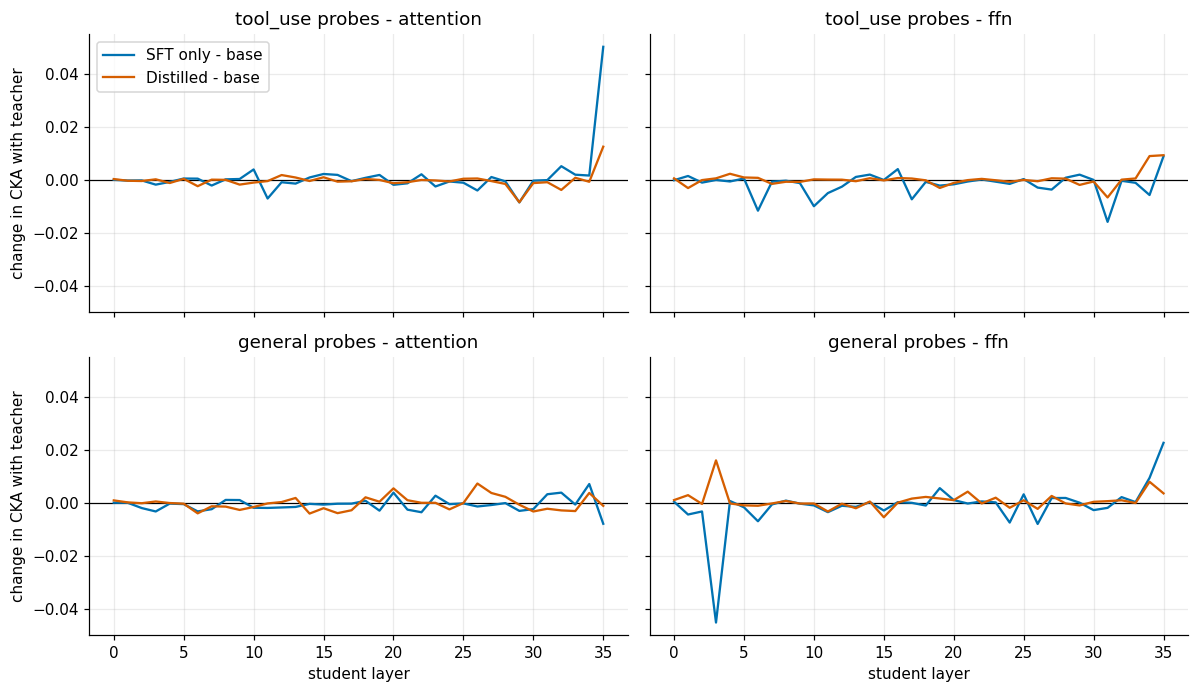

tool_use: distilled closer to teacher than SFT-only in 37/72 layer-streams; mean |distilled - SFT| = 0.0028, mean |SFT - base| = 0.0029
general: distilled closer to teacher than SFT-only in 43/72 layer-streams; mean |distilled - SFT| = 0.0034, mean |SFT - base| = 0.0030
mean |change in CKA vs base| over all layer-streams: SFT only 0.0029, distilled 0.0017; largest single change: SFT only 0.050, distilled 0.016


In [9]:
piv = div.pivot_table(index=["input_set", "stream", "source_layer"], columns="condition", values="cka").reset_index()
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), sharex=True, sharey=True)
for r, input_set in enumerate(["tool_use", "general"]):
    for c_idx, stream in enumerate(["attention", "ffn"]):
        ax = axes[r][c_idx]
        d = piv[(piv.input_set == input_set) & (piv.stream == stream)].sort_values("source_layer")
        ax.axhline(0, color="black", lw=0.8)
        ax.plot(d["source_layer"], d["sft_only"] - d["base"], color=COLORS["sft_only"], label="SFT only - base")
        ax.plot(d["source_layer"], d["distilled"] - d["base"], color=COLORS["distilled"], label="Distilled - base")
        ax.set_title(f"{input_set} probes - {stream}")
        if r == 1:
            ax.set_xlabel("student layer")
        if c_idx == 0:
            ax.set_ylabel("change in CKA with teacher")
axes[0][0].legend()
fig.tight_layout()
fig.savefig(FIG / "layer_cka_change_vs_base.png", dpi=200)
plt.show()

for input_set in ["tool_use", "general"]:
    q = piv[piv.input_set == input_set]
    print(f"{input_set}: distilled closer to teacher than SFT-only in {(q.distilled > q.sft_only).sum()}/{len(q)} layer-streams; "
          f"mean |distilled - SFT| = {(q.distilled - q.sft_only).abs().mean():.4f}, mean |SFT - base| = {(q.sft_only - q.base).abs().mean():.4f}")

both = piv.assign(sft_move=(piv.sft_only - piv.base).abs(), dist_move=(piv.distilled - piv.base).abs())
print(f"mean |change in CKA vs base| over all layer-streams: SFT only {both.sft_move.mean():.4f}, distilled {both.dist_move.mean():.4f}; "
      f"largest single change: SFT only {both.sft_move.max():.3f}, distilled {both.dist_move.max():.3f}")

On these probes the three students are equally similar to the teacher, layer by layer: the average CKA differs in the third decimal, and the gap between distilled and SFT-only is the same size as the gap between SFT-only and the untouched base. So the behavioural advantage of the distilled student is **not** accompanied by a measurable shift of its layers toward the teacher's here. The hypothesis "distillation works by pulling student representations toward the teacher" is not supported by this measurement.

Where the students do move, SFT-only moves more: its representations change more than the distilled student's (larger mean change and larger spikes, mostly in the last layers), and the distilled student stays closer to the base. That is consistent with the KD term acting as a regulariser, but the changes are small and the probe set is small, so treat it as a lead for a follow-up rather than a finding.

That is a statement about this measurement, not about representations in general: 50 mean-pooled probe texts per set, short user requests rather than full prompt-plus-completion sequences, one seed, and a LoRA update small enough that even the base student already sits at CKA 0.84 with the teacher.

## 6. Limitations

- One training run and one evaluation seed: no estimate of run-to-run variance. The two trained students differ only in the loss, but a second seed could still move the chain-3/5 gap.
- 121 evaluation tasks from a small set of templates; per-length cells have 35-46 tasks, so the template-level intervals above are wide.
- The evaluation vocabulary (six tools) differs from the training vocabulary (eight Glaive tools), so the metric is generalisation to unseen tools, and the grader checks tool names and order, not argument values.
- Training data is small (640 examples) and highly templated; the SFT-only loss collapse suggests memorisation.
- Layer analysis: mean-pooled sequences, 50 probes per set, linear CKA and RSA cosine only; it cannot rule out differences at finer granularity.